<a href="https://colab.research.google.com/github/gilbmura/Principle_Component_Analysis/blob/main/PCA_Formative_2_Group_58.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

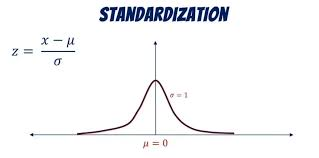


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

In [ ]:
FILE = "/content/co2 Emission Africa.csv"

# Numeric feature columns are indices 4..19 (skip Country, Sub-Region, Code, Year)
feature_names = [
    "Population", "GDP per capita (USD)", "GDP per capita PPP (USD)", "Area (Km2)",
    "Transportation", "Total CO2 incl LUCF", "Total CO2 excl LUCF", "Other Fuel Combustion",
    "Manufacturing/Construction", "Land-Use Change & Forestry", "Industrial Processes",
    "Fugitive Emissions", "Energy", "Electricity/Heat", "Bunker Fuels", "Building",
]

raw = np.genfromtxt(FILE, delimiter=",", skip_header=1, usecols=range(4, 20), dtype=float)
print("Raw feature matrix shape:", raw.shape)
print("Missing (NaN) values:", int(np.isnan(raw).sum()))

Raw feature matrix shape: (1134, 16)
Missing (NaN) values: 1013


In [ ]:
# Impute missing values with the column mean (NumPy only)
col_means = np.nanmean(raw, axis=0)
nan_idx = np.where(np.isnan(raw))
raw[nan_idx] = np.take(col_means, nan_idx[1])
print("Missing values after imputation:", int(np.isnan(raw).sum()))

Missing values after imputation: 0


In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mean = raw.mean(axis=0)
std = raw.std(axis=0)                       # population std (ddof=0)

standardized_data = (raw - mean) / std      # z = (x - mu) / sigma
standardized_data[:5]  # Display the first few rows of standardized data

array([[ 0.3832, -0.1498,  0.581 ,  3.0517,  1.1071,  0.4423,  0.9529,
        -0.367 ,  0.4654, -0.2971,  0.9427,  2.374 ,  0.9366,  0.5202,
         0.6399,  1.8405],
       [ 0.398 , -0.1586,  0.6374,  3.0517,  1.1248,  0.3931,  0.9304,
        -0.367 ,  0.477 , -0.3417,  0.9356,  1.7002,  0.9137,  0.5472,
         0.6505,  1.8873],
       [ 0.4127, -0.1449,  0.7251,  3.0517,  1.3399,  0.4354,  0.9907,
        -0.367 ,  0.5247, -0.3417,  1.0378,  1.3132,  0.9712,  0.6015,
         0.7514,  1.9714],
       [ 0.4277, -0.0351,  0.8503,  3.0517,  1.5625,  0.5003,  1.0839,
        -0.367 ,  0.5749, -0.3417,  1.0273,  1.7725,  1.0675,  0.6081,
         0.6028,  2.156 ],
       [ 0.4435,  0.1379,  0.9468,  3.0517,  1.5876,  0.515 ,  1.1048,
        -0.367 ,  0.7141, -0.3417,  1.3339,  1.551 ,  1.0748,  0.5877,
         0.762 ,  2.3523]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate the Covariance Matrix
n = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)
cov_matrix

array([[ 1.0009, -0.1183, -0.0836,  0.4514,  0.6663,  0.5577,  0.455 ,
         0.4766,  0.4093,  0.3197,  0.5612,  0.4274,  0.4421,  0.2992,
         0.4027,  0.3749],
       [-0.1183,  1.0009,  0.9483,  0.0069,  0.1995,  0.0684,  0.2275,
         0.1632,  0.1977, -0.1205,  0.0956, -0.0218,  0.2297,  0.2251,
         0.2467,  0.1984],
       [-0.0836,  0.9483,  1.0009,  0.0927,  0.2896,  0.0917,  0.2843,
         0.2032,  0.2548, -0.1423,  0.2073,  0.0061,  0.2829,  0.2539,
         0.2789,  0.2766],
       [ 0.4514,  0.0069,  0.0927,  1.0009,  0.4369,  0.5662,  0.3395,
         0.2765,  0.2733,  0.4383,  0.3118,  0.1354,  0.3354,  0.2582,
         0.2768,  0.3963],
       [ 0.6663,  0.1995,  0.2896,  0.4369,  1.0009,  0.6016,  0.8931,
         0.8134,  0.8358, -0.0293,  0.8256,  0.2998,  0.881 ,  0.755 ,
         0.7567,  0.8665],
       [ 0.5577,  0.0684,  0.0917,  0.5662,  0.6016,  1.0009,  0.6622,
         0.5593,  0.6276,  0.7173,  0.4136,  0.0054,  0.6626,  0.6374,
         0.61

We compute it because PCA needs to know the **structure of variation** in the data, and the
covariance matrix captures exactly that. *Reason 1:* its off-diagonal entries quantify how strongly
features move together, revealing the correlated groups of features that PCA will collapse into
single components. *Reason 2:* PCA is mathematically the **eigen-decomposition of this matrix** —
its eigenvectors point along the directions of maximum variance, and its eigenvalues measure how
much variance lies along each, which is the entire basis for ranking and selecting components.

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues, eigenvectors

(array([0.    , 0.    , 0.0018, 0.0155, 0.0359, 0.0458, 0.0826, 0.1032,
        0.2225, 0.307 , 0.5491, 0.667 , 1.3921, 1.5857, 2.2969, 8.709 ]),
 array([[ 0.    ,  0.0004,  0.0144,  0.0871, -0.2346,  0.1818, -0.2686,
          0.1387,  0.0201,  0.6202, -0.361 ,  0.0472, -0.35  ,  0.0153,
          0.3691, -0.1899],
        [-0.    , -0.0006, -0.018 , -0.0327,  0.5071,  0.4498, -0.1239,
          0.0095,  0.0803,  0.0783, -0.1348, -0.0453, -0.1908, -0.4944,
         -0.4504, -0.0845],
        [ 0.    ,  0.0007,  0.0309,  0.0498, -0.5872, -0.3875,  0.0964,
          0.0049, -0.0357,  0.0098, -0.0341,  0.0676, -0.2319, -0.4772,
         -0.4385, -0.1067],
        [-0.    , -0.0008,  0.0017, -0.003 ,  0.0393,  0.0831,  0.1314,
         -0.0771,  0.1073,  0.2131,  0.7897,  0.2183, -0.1149, -0.3223,
          0.3177, -0.1488],
        [ 0.    ,  0.0019,  0.1955, -0.4227,  0.4073, -0.524 , -0.0265,
          0.4037, -0.0851, -0.0033, -0.0253,  0.1315, -0.2194,  0.0655,
          0.033 , -0.3

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]   # indices of eigenvalues, descending
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sorted_eigenvectors

array([[-0.1899,  0.3691,  0.0153, -0.35  ,  0.0472, -0.361 ,  0.6202,
         0.0201,  0.1387, -0.2686,  0.1818, -0.2346,  0.0871,  0.0144,
         0.0004,  0.    ],
       [-0.0845, -0.4504, -0.4944, -0.1908, -0.0453, -0.1348,  0.0783,
         0.0803,  0.0095, -0.1239,  0.4498,  0.5071, -0.0327, -0.018 ,
        -0.0006, -0.    ],
       [-0.1067, -0.4385, -0.4772, -0.2319,  0.0676, -0.0341,  0.0098,
        -0.0357,  0.0049,  0.0964, -0.3875, -0.5872,  0.0498,  0.0309,
         0.0007,  0.    ],
       [-0.1488,  0.3177, -0.3223, -0.1149,  0.2183,  0.7897,  0.2131,
         0.1073, -0.0771,  0.1314,  0.0831,  0.0393, -0.003 ,  0.0017,
        -0.0008, -0.    ],
       [-0.3166,  0.033 ,  0.0655, -0.2194,  0.1315, -0.0253, -0.0033,
        -0.0851,  0.4037, -0.0265, -0.524 ,  0.4073, -0.4227,  0.1955,
         0.0019,  0.    ],
       [-0.2448,  0.311 , -0.3188,  0.1885, -0.1489, -0.1714, -0.2081,
        -0.0558,  0.0705,  0.07  , -0.0253,  0.0116,  0.0487, -0.2007,
        -0.25

In [ ]:
# Explained variance per component (used to answer the question below)
explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative = np.cumsum(explained_variance_ratio)
for i, (ev, cv) in enumerate(zip(explained_variance_ratio, cumulative), 1):
    print(f"PC{i:2d}:  {ev*100:6.2f}%   cumulative {cv*100:6.2f}%")

PC 1:   54.38%   cumulative  54.38%
PC 2:   14.34%   cumulative  68.73%
PC 3:    9.90%   cumulative  78.63%
PC 4:    8.69%   cumulative  87.32%
PC 5:    4.16%   cumulative  91.49%
PC 6:    3.43%   cumulative  94.92%
PC 7:    1.92%   cumulative  96.83%
PC 8:    1.39%   cumulative  98.22%
PC 9:    0.64%   cumulative  98.87%
PC10:    0.52%   cumulative  99.38%
PC11:    0.29%   cumulative  99.67%
PC12:    0.22%   cumulative  99.89%
PC13:    0.10%   cumulative  99.99%
PC14:    0.01%   cumulative 100.00%
PC15:    0.00%   cumulative 100.00%
PC16:    0.00%   cumulative 100.00%


**How is explained variance used in PCA? (max 5 lines)**

Each eigenvalue divided by the sum of all eigenvalues gives the **fraction of total variance** that
its component captures. We use these ratios to **rank** the components and to **decide how many to
keep**: by reading the cumulative curve we retain the smallest set of components that preserves a
chosen share of the variance (e.g. 90% or 95%), discarding the rest as low-information directions.

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
threshold = 0.90
num_components = int(np.searchsorted(cumulative, threshold) + 1)  # smallest k >= 90%
print(f"Keeping {num_components} components -> {cumulative[num_components-1]*100:.2f}% variance retained")

W = sorted_eigenvectors[:, :num_components]      # projection matrix
reduced_data = standardized_data @ W             # project
reduced_data[:5]

Keeping 5 components -> 91.49% variance retained


array([[-2.9673,  0.9702, -0.3499, -2.2057, -0.2192],
       [-2.9517,  0.8258, -0.4196, -1.7659,  0.1652],
       [-3.1804,  0.7309, -0.4798, -1.5397,  0.4285],
       [-3.403 ,  0.7069, -0.5135, -1.9468,  0.2175],
       [-3.6674,  0.5468, -0.6039, -1.8789,  0.5278]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Original Data Shape: {standardized_data.shape}')
print(f'Reduced Data Shape : {reduced_data.shape}')
reduced_data[:5]

Original Data Shape: (1134, 16)
Reduced Data Shape : (1134, 5)


array([[-2.9673,  0.9702, -0.3499, -2.2057, -0.2192],
       [-2.9517,  0.8258, -0.4196, -1.7659,  0.1652],
       [-3.1804,  0.7309, -0.4798, -1.5397,  0.4285],
       [-3.403 ,  0.7069, -0.5135, -1.9468,  0.2175],
       [-3.6674,  0.5468, -0.6039, -1.8789,  0.5278]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

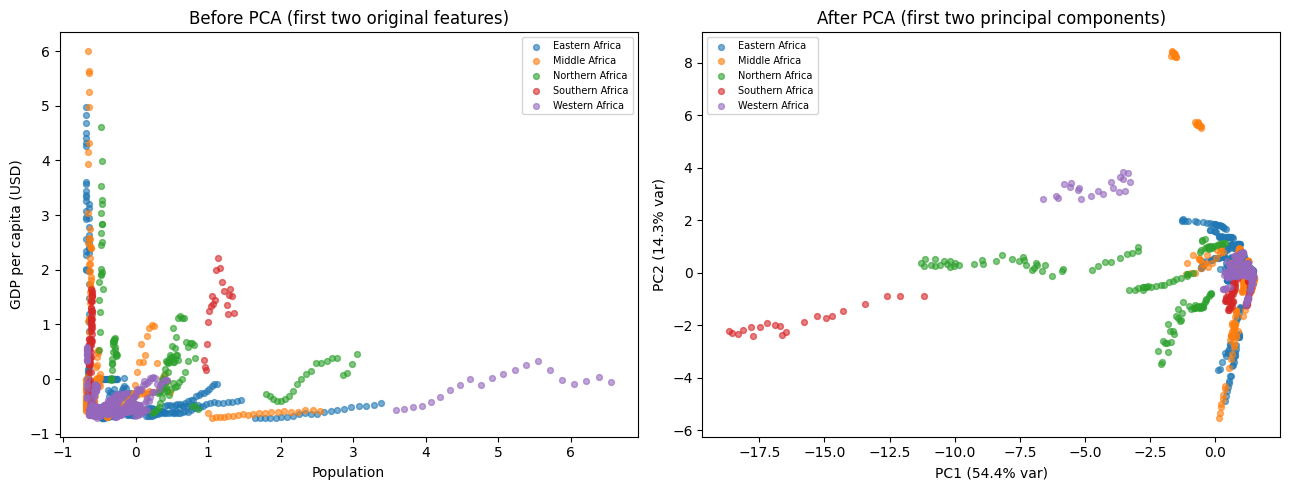

In [ ]:
# Load region labels (non-numeric column) for colouring
regions = np.genfromtxt(FILE, delimiter=",", skip_header=1, usecols=1, dtype=str)
unique_regions = np.unique(regions)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot original data (first two features for simplicity) -- standardized for comparability
for r in unique_regions:
    m = regions == r
    axes[0].scatter(standardized_data[m, 0], standardized_data[m, 1], s=18, alpha=0.6, label=r)
axes[0].set_title("Before PCA (first two original features)")
axes[0].set_xlabel(feature_names[0]); axes[0].set_ylabel(feature_names[1])
axes[0].legend(fontsize=7)

# Plot reduced data after PCA (first two principal components)
for r in unique_regions:
    m = regions == r
    axes[1].scatter(reduced_data[m, 0], reduced_data[m, 1], s=18, alpha=0.6, label=r)
axes[1].set_title("After PCA (first two principal components)")
axes[1].set_xlabel(f"PC1 ({explained_variance_ratio[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({explained_variance_ratio[1]*100:.1f}% var)")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA

 In the *before* plot the points spread along two correlated raw features and the regions overlap
heavily, so structure is hard to read in just two of the sixteen original dimensions. In the
*after* plot the same countries are re-expressed on PC1–PC2, where PC1 spreads them along a single
dominant axis; a large share of the total variation is now visible in only two axes instead of
sixteen, while points still cluster similarly — showing the reduction kept the main structure.


2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

 We kept `num_components` components because that is the smallest number reaching ~90% cumulative
variance (see Step 6). Keeping fewer makes the data smaller, faster, and easier to plot and removes
noise, but each dropped component is a real orthogonal direction of variation, so the trade-off is
**compactness vs. completeness**: we accept losing ~10% of the variance — mostly the minor,
country-specific differences — in exchange for a far simpler representation.

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

 PC1 here is essentially an **economic-activity / population-pressure / total-emissions "size" axis**:
big, high-emitting economies sit at one end and small ones at the other, and the top components
preserve that story well. What is lost are the **finer sectoral distinctions** — e.g. a country
whose emissions come mainly from *land-use change* rather than *energy*, or one with an atypical
*fugitive-emissions* profile, can look identical to its neighbours once the low-variance components
are dropped, even though those nuances matter for climate policy.

